# The StockKeep Class — End-to-End Inventory Planning

`StockKeep` is the top-level orchestrator in OptiStock. It chains four stages into a single call:

> **Fit forecaster → Forecast demand → Optimise allocation → Evaluate**

It supports two modes:

| Mode | Method | Purpose |
|---|---|---|
| **Holdout validation** | `run_holdout(holdout_days)` | Withhold recent history, forecast it, then compare the optimised allocation against what actually happened — use this to verify the methodology before going live |
| **Production** | `run(forecast_days)` | Fit on all available data and produce an allocation for the next *n* days |

Both modes accept the same solver and objective parameters (`objective`, `limits`, `cvar_alpha`, …), so you can test a risk-averse strategy in holdout mode before committing to it in production.

History: 1,460 rows | 2 items | 2022-01-01 → 2023-12-31


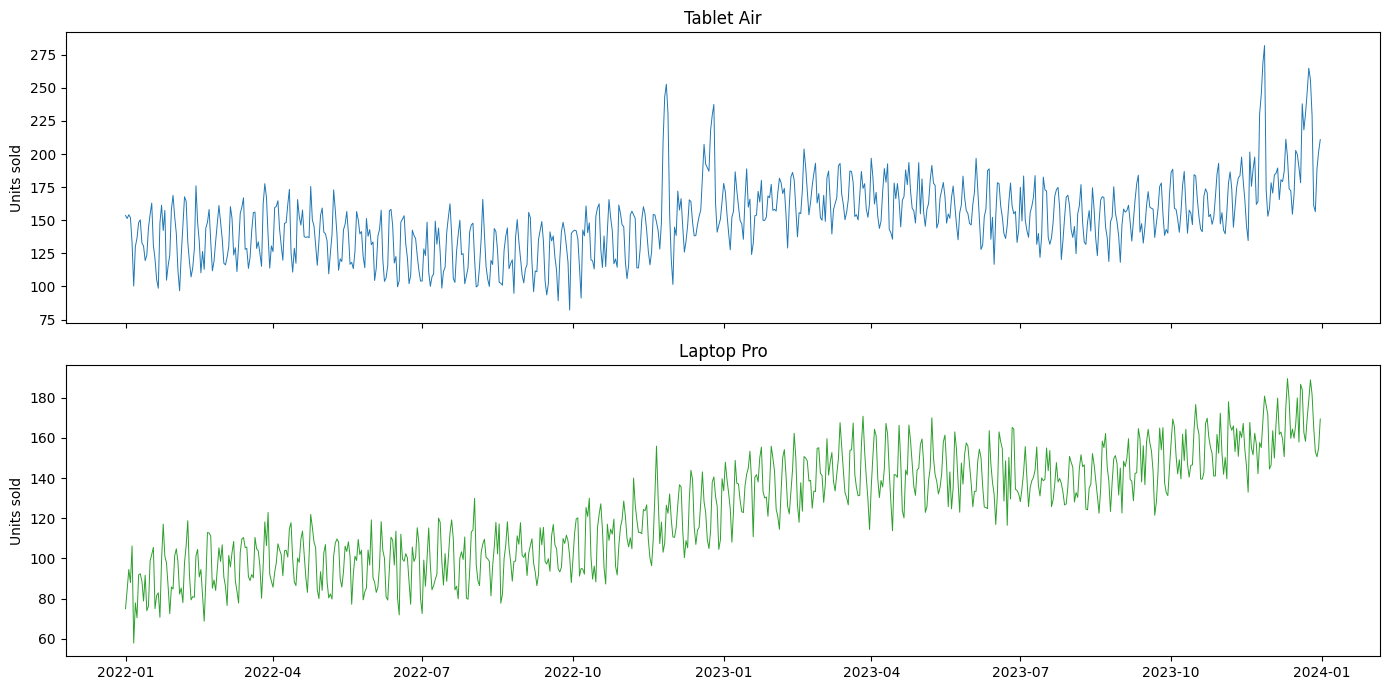

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

# ── Synthetic histories ────────────────────────────────────────────────────
# Two years of daily sales for two products.
#
# Tablet Air — consumer electronics:
#   · Moderate upward trend
#   · Strong weekend spike (people buy on Saturdays)
#   · Annual wave (Q4 gifting season peak)
#   · Black Friday and Christmas event spikes
#   · BetaYield(8, 2): ~80% of ordered units pass quality control
#
# Laptop Pro — business laptop:
#   · Steeper trend (enterprise demand growing)
#   · Mild weekly pattern (purchases cluster Mon–Wed)
#   · Softer seasonal curve
#   · Perfect yield (all ordered units arrive)

N = 730
dates = pd.date_range("2022-01-01", periods=N, freq="D")
t = np.arange(N)

# ── Tablet Air ─────────────────────────────────────────────────────────────
trend_ta      = 120 + 0.08 * t
weekly_ta     = 18 * np.sin(2 * np.pi * t / 7) + 8 * np.cos(2 * np.pi * t / 7)
yearly_ta     = (12 * np.sin(2 * np.pi * t / 365.25)
               +  8 * np.cos(2 * np.pi * t / 365.25))

event_ta = np.zeros(N)
for i, d in enumerate(dates):
    if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28:   # Black Friday
        event_ta[i : min(i + 4, N)] += 80
    if d.month == 12 and 20 <= d.day <= 26:                         # Christmas week
        event_ta[i] += 60

sales_ta = trend_ta + weekly_ta + yearly_ta + event_ta + np.random.normal(0, 10, N)

# ── Laptop Pro ─────────────────────────────────────────────────────────────
trend_lp   = 80 + 0.12 * t
weekly_lp  = 12 * np.sin(2 * np.pi * t / 7) - 6 * np.cos(2 * np.pi * t / 7)
yearly_lp  = (8 * np.sin(2 * np.pi * t / 365.25)
            + 5 * np.cos(2 * np.pi * t / 365.25))

sales_lp = trend_lp + weekly_lp + yearly_lp + np.random.normal(0, 8, N)

# ── Combine into long-format DataFrame ─────────────────────────────────────
df_ta = pd.DataFrame({
    "item":  "Tablet Air",
    "date":  dates.astype(str),
    "sales": np.maximum(sales_ta, 5).round(1),
})
df_lp = pd.DataFrame({
    "item":  "Laptop Pro",
    "date":  dates.astype(str),
    "sales": np.maximum(sales_lp, 5).round(1),
})
df_history = pd.concat([df_ta, df_lp], ignore_index=True)

print(f"History: {df_history.shape[0]:,} rows | {df_history['item'].nunique()} items | "
      f"{df_history['date'].min()} → {df_history['date'].max()}")

# ── Quick overview ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, item, color in zip(axes, ["Tablet Air", "Laptop Pro"], ["tab:blue", "tab:green"]):
    sub = df_history[df_history["item"] == item]
    ax.plot(pd.to_datetime(sub["date"]), sub["sales"], lw=0.7, color=color)
    ax.set_title(item)
    ax.set_ylabel("Units sold")
plt.tight_layout()

In [2]:
from optistock.stockkeep import StockKeep
from optistock.forecasting.linear_regressors import BayesTimeSeries
from optistock.distributions.yield_distributions import BetaYield

# ── Item configuration ──────────────────────────────────────────────────────
# Required columns:   name, cost_price, selling_price
# Optional columns:   salvage_value (defaults to 0), plus any resource columns
#                     (extra columns become constraint coefficients on the solver)
item_configs = pd.DataFrame([
    {
        "name":          "Tablet Air",
        "cost_price":    120,
        "selling_price": 250,
        "salvage_value":  40,
        "storage_m3":    0.8,   # cubic metres of warehouse space per unit
    },
    {
        "name":          "Laptop Pro",
        "cost_price":    400,
        "selling_price": 750,
        "salvage_value": 100,
        "storage_m3":    2.0,
    },
])

# ── Forecaster configuration ────────────────────────────────────────────────
# We use BayesTimeSeries for both items.  The seasonal_config is passed via
# forecaster_kwargs and applied at construction time for every item.
seasonal_config = {
    "weekly": (7, 3),          # 7-day period, 3 sin/cos pairs
    "yearly": (365.25, 4),     # yearly cycle, 4 harmonics
}

# ── Yield distributions ─────────────────────────────────────────────────────
# Tablet Air has imperfect yield: on average 80% of ordered units pass QC.
# Laptop Pro is assumed to have perfect yield (all units arrive as ordered).
yield_profiles = {
    "Laptop Pro": BetaYield(80, 20),    # mean = 80/(80+20) = 80%
}

# ── Instantiate StockKeep ───────────────────────────────────────────────────
sk = StockKeep(
    histories=df_history,
    item_configs=item_configs,
    forecaster_class=BayesTimeSeries,
    forecaster_kwargs={"seasonal_config": seasonal_config},
    yield_profiles=yield_profiles,
    target="sales",
    date_col="date",
    item_col="item",
)

print("Items registered:")
for item in sk.items:
    cf = item.critical_fractile
    print(f"  {item.name:12s}  cost={item.cost_price:>4}  sell={item.selling_price:>4}  "
          f"salvage={item.salvage_value:>4}  critical_fractile={cf:.3f}")

Items registered:
  Tablet Air    cost=120.0  sell=250.0  salvage=40.0  critical_fractile=0.619
  Laptop Pro    cost=400.0  sell=750.0  salvage=100.0  critical_fractile=0.538


---
## Holdout Validation

Before committing to a strategy in production, use `run_holdout` to back-test it against real history.

`StockKeep` withholds the last `holdout_days` calendar days from each item's history, fits the forecaster on everything before that window, and then:
1. Generates a forecast over the withheld window.
2. Passes `(Item, fitted_forecaster)` pairs to `ForecastSolver` to find the optimal order quantities.
3. Simulates what would have happened if those quantities had been ordered — using the *actual* holdout sales as ground truth.

The returned `metrics` dict reports per-item profit, service level, stockout flag, leftover units, and **SMAPE** (forecast accuracy).

### Objective: CVaR
We use the CVaR objective here to protect against the worst 10% of demand scenarios.  This is appropriate for the Tablet Air whose yield adds extra uncertainty on top of forecast uncertainty.

In [3]:
# ── Known promotional events for Tablet Air ────────────────────────────────
all_dates = pd.to_datetime(df_history["date"].unique())
bf_dates   = [d for d in all_dates if d.month == 11 and d.weekday() == 4 and 22 <= d.day <= 28]
xmas_dates = [d for d in all_dates if d.month == 12 and 20 <= d.day <= 26]

events = {
    "Tablet Air": {
        "black_friday": [str(d.date()) for d in bf_dates],
        "christmas":    [str(d.date()) for d in xmas_dates],
    }
    # No events registered for Laptop Pro (business demand, no major promo spikes)
}

# ── Run holdout validation ─────────────────────────────────────────────────
# Withhold the last 30 days.
# Solver: CVaR (alpha=0.10 → protect the worst 10% of scenarios, lambda=0.60).
# Constraint: combined warehouse space ≤ 5,000 m³.
holdout_results = sk.run_holdout(
    holdout_days=14,
    events=events,
    objective="CVaR",
    limits={"storage_m3": 5_000},
    cvar_alpha=0.10,
    cvar_lambda=0.4,
    fit_kwargs={"chain": 2, "samples": 500},
)

print("Planning period:", holdout_results["period"])
print("Mode           :", holdout_results["mode"])

Initializing NUTS using jitter+adapt_diag...
c:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 21 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Output()

Sampling: [y]


Output()

Planning period: ('2023-12-18', '2023-12-31')
Mode           : holdout


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:237: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))


In [4]:
# ── Allocation and per-item metrics ───────────────────────────────────────
allocation = holdout_results["allocation"]
metrics    = holdout_results["metrics"]

print("=" * 60)
print(f"{'ALLOCATION & HOLDOUT PERFORMANCE':^60}")
print("=" * 60)

for item in sk.items:
    m   = metrics[item.name]
    qty = allocation[item.name]
    print(f"\n  {item.name}")
    print(f"    Order quantity : {qty:>6,} units")
    print(f"    Profit         : R{m['profit']:>10,.0f}")
    print(f"    Service level  : {m['service_level']:.1%}   (fraction of demand met)")
    print(f"    Stockout       : {'Yes ⚠' if m['stockout'] else 'No'}")
    print(f"    Leftover units : {m['leftover_units']:>6,}")
    if "smape_pct" in m:
        print(f"    Forecast SMAPE : {m['smape_pct']:.1f}%")

print()
print(f"  Portfolio total profit : R{metrics['portfolio_total_profit']:>12,.0f}")

              ALLOCATION & HOLDOUT PERFORMANCE              

  Tablet Air
    Order quantity :  2,936 units
    Profit         : R   381,680
    Service level  : 98.9%   (fraction of demand met)
    Stockout       : Yes ⚠
    Leftover units :      0
    Forecast SMAPE : 3.9%

  Laptop Pro
    Order quantity :  1,325 units
    Profit         : R   463,750
    Service level  : 56.1%   (fraction of demand met)
    Stockout       : Yes ⚠
    Leftover units :      0
    Forecast SMAPE : 4.5%

  Portfolio total profit : R     845,430


## Forecast visualisation

`plot_forecast()` overlays the forecast HDI against actual holdout observations.
A well-calibrated model should have most of the actuals (crosses) sitting inside the 94% HDI band.

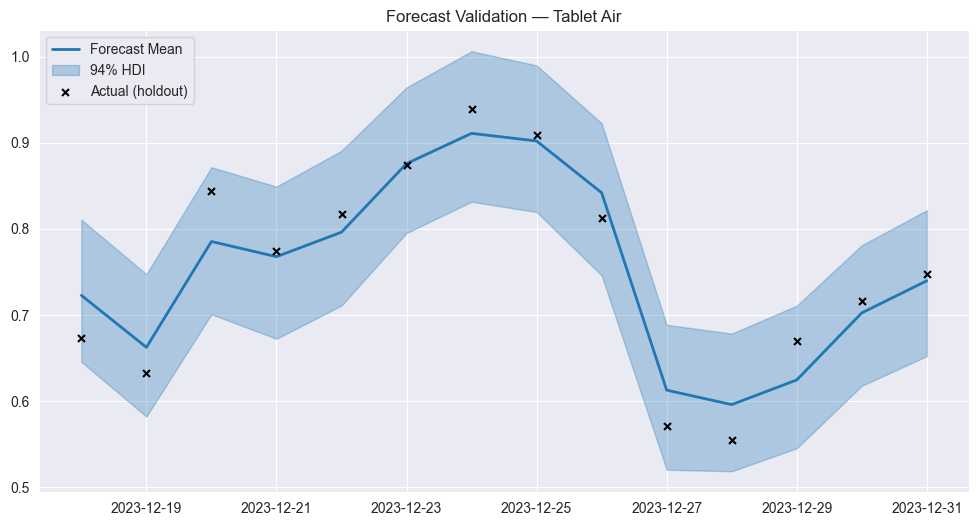

In [5]:
fig, ax = sk.plot_forecast("Tablet Air")

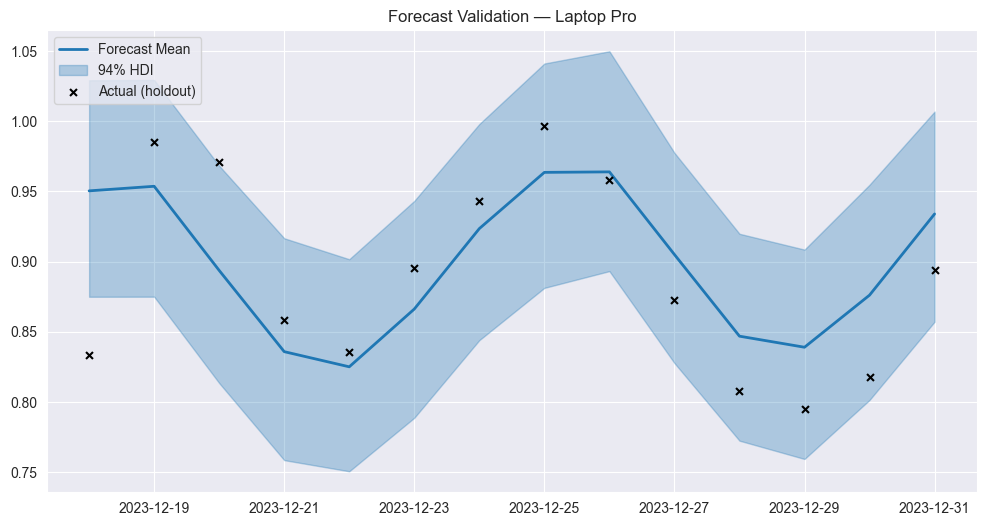

In [6]:
fig, ax = sk.plot_forecast("Laptop Pro")

## Solver diagnostic summary

`summary()` calls `ForecastSolver.summary()` on the last solve.  
It reports the distribution of portfolio profit across all posterior scenarios — useful for checking whether the CVaR tail is where you expected it to be.

In [7]:
summary = sk.summary()
for k, v in summary.items():
    if k == "allocation":
        continue
    if isinstance(v, dict):
        print(f"{k}:")
        for kk, vv in v.items():
            print(f"    {kk}: {vv:.2f}")
    elif isinstance(v, float):
        print(f"{k}: {v:,.2f}")
    else:
        print(f"{k}: {v}")

expected_profit: 644,728.92
profit_std: 39,433.20
cvar_10pct: 571,431.23
service_level: 0.00
certainty_equivalent: 0.00
risk_premium: 644,728.92
shadow_prices:
    storage_m3: 89.09


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:237: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))


## Plot Results

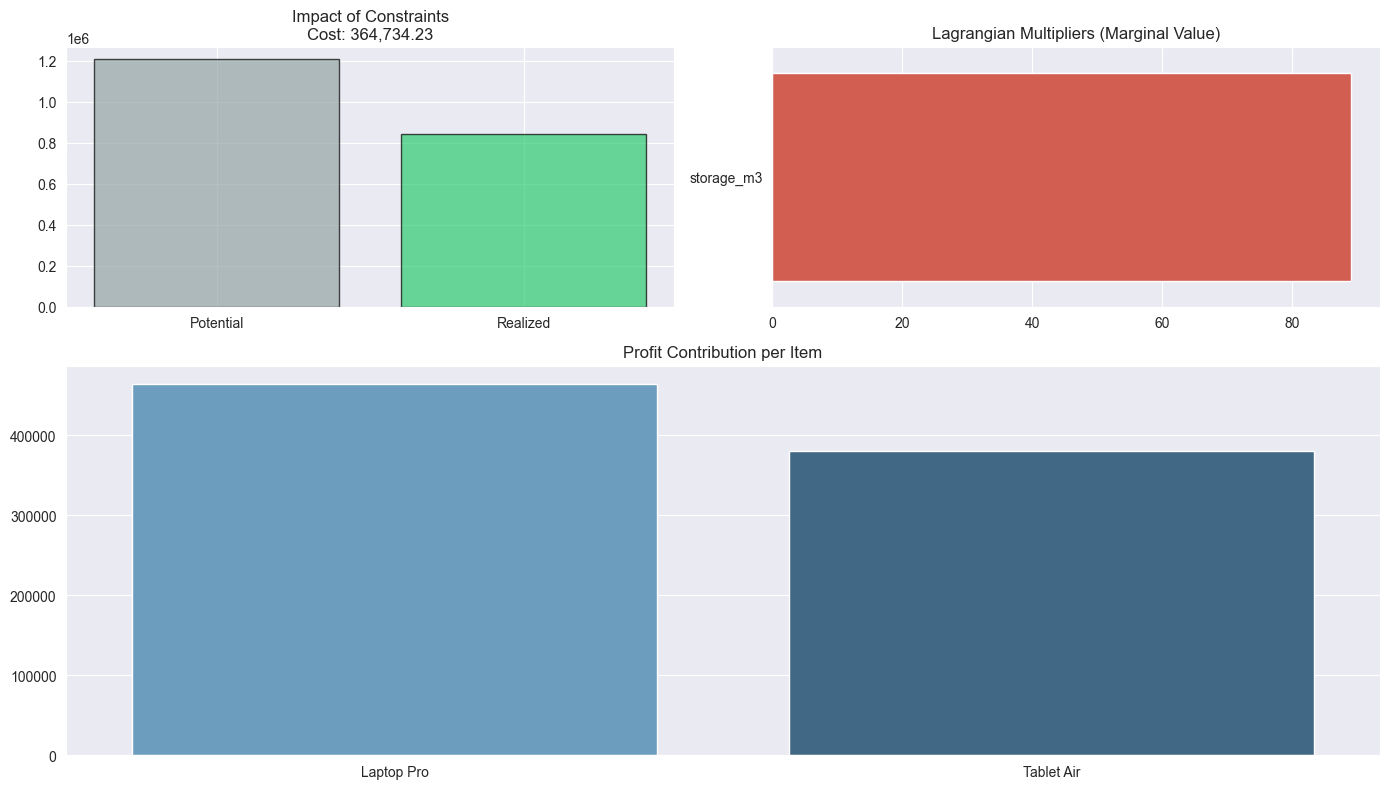

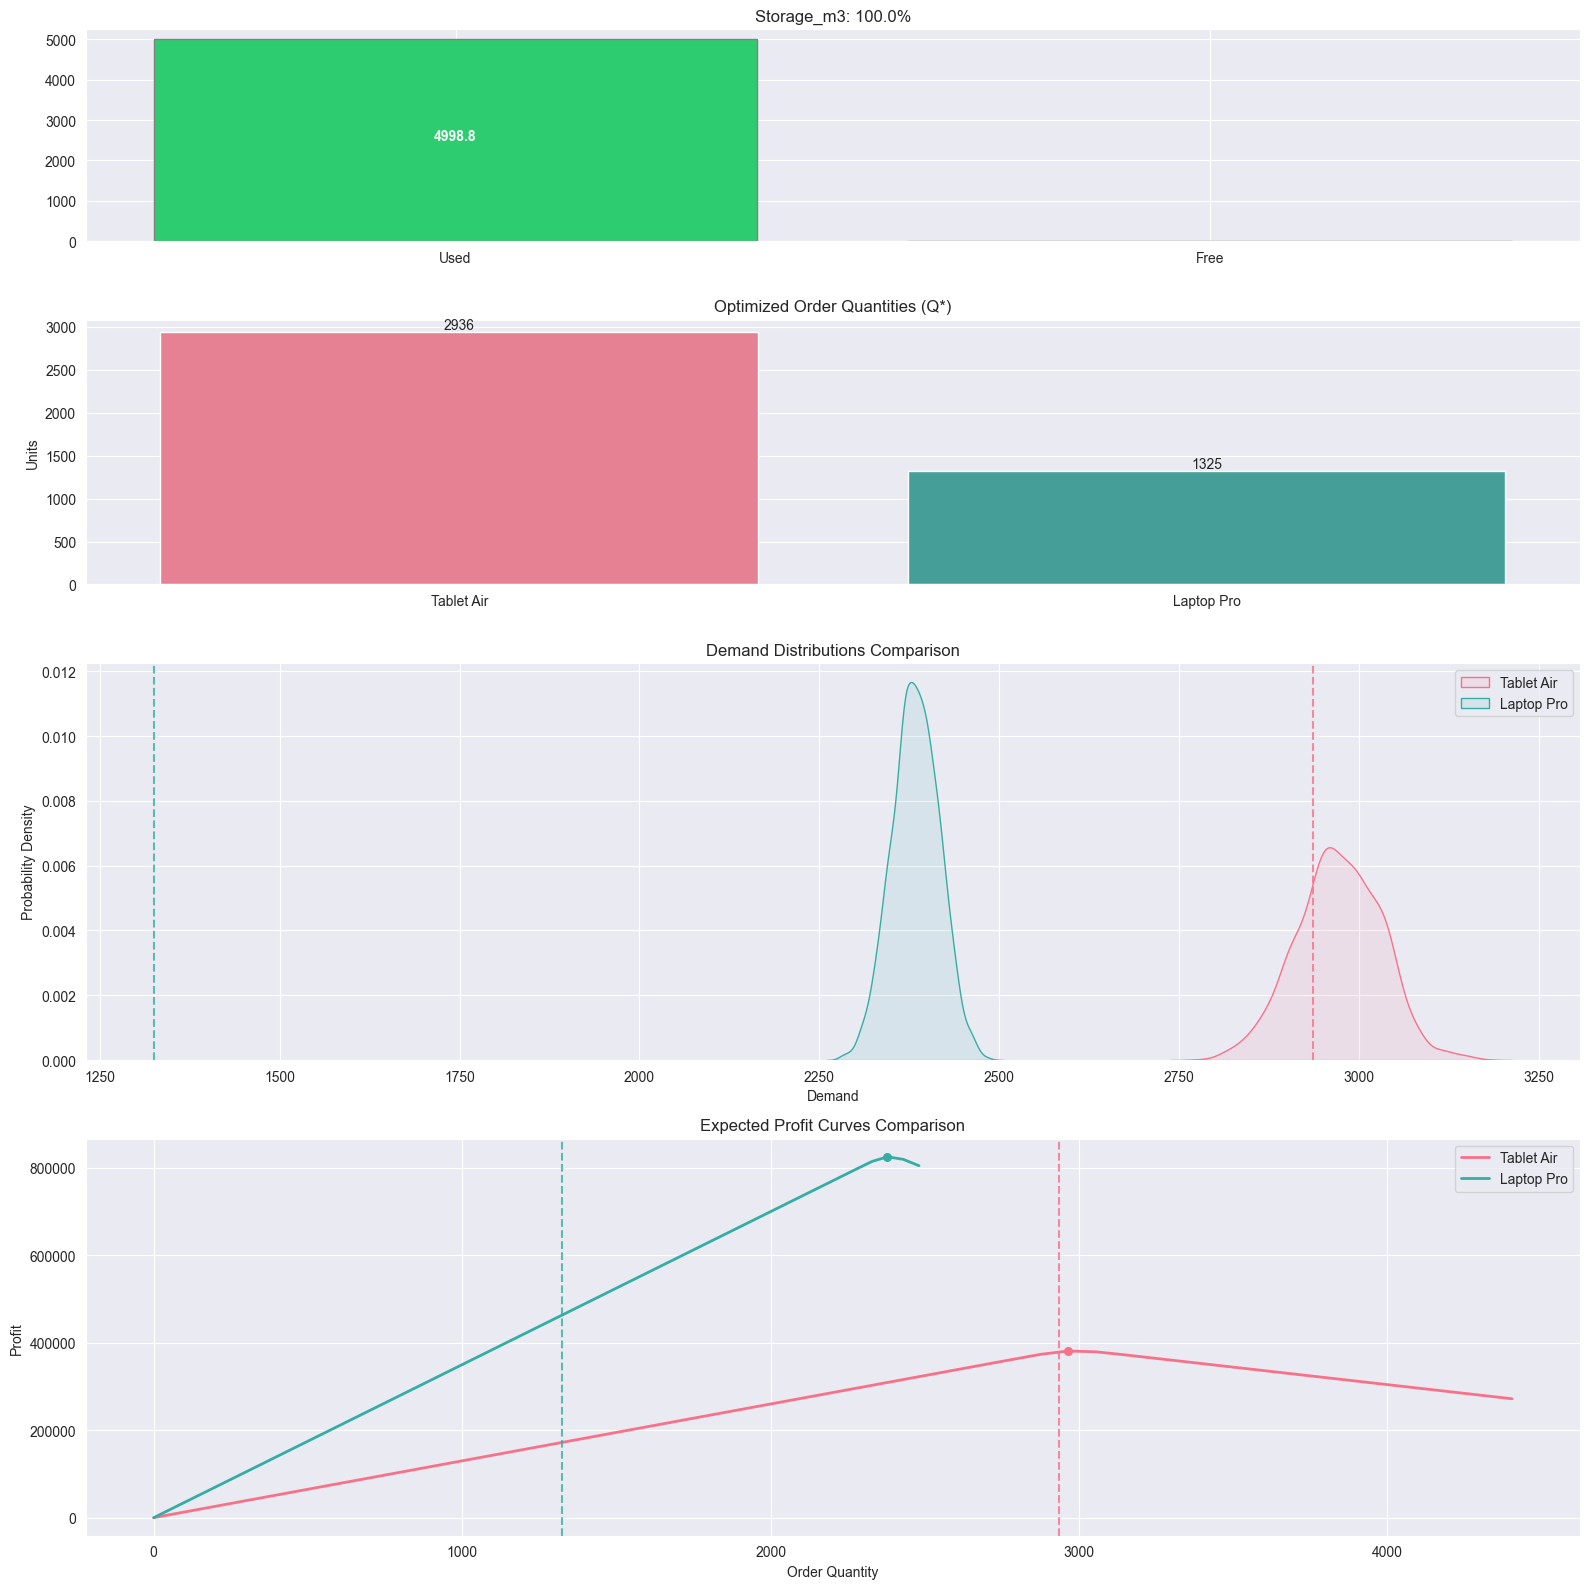

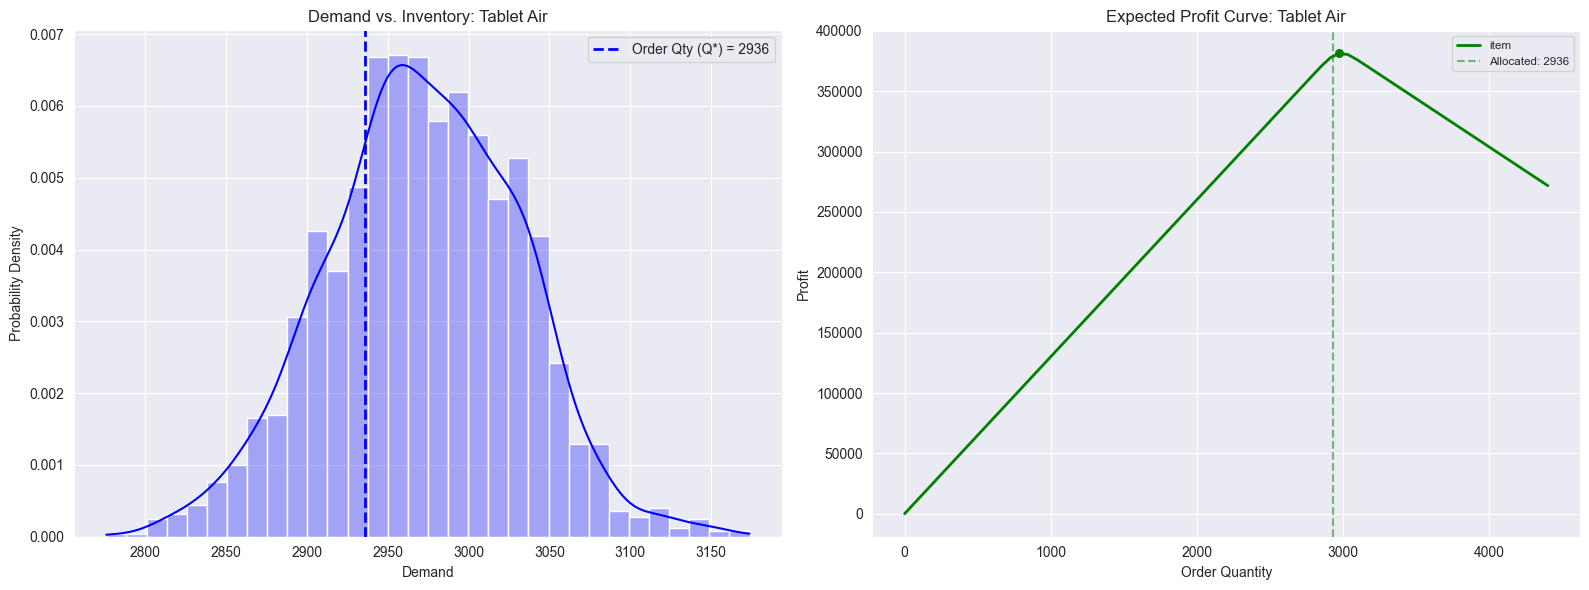

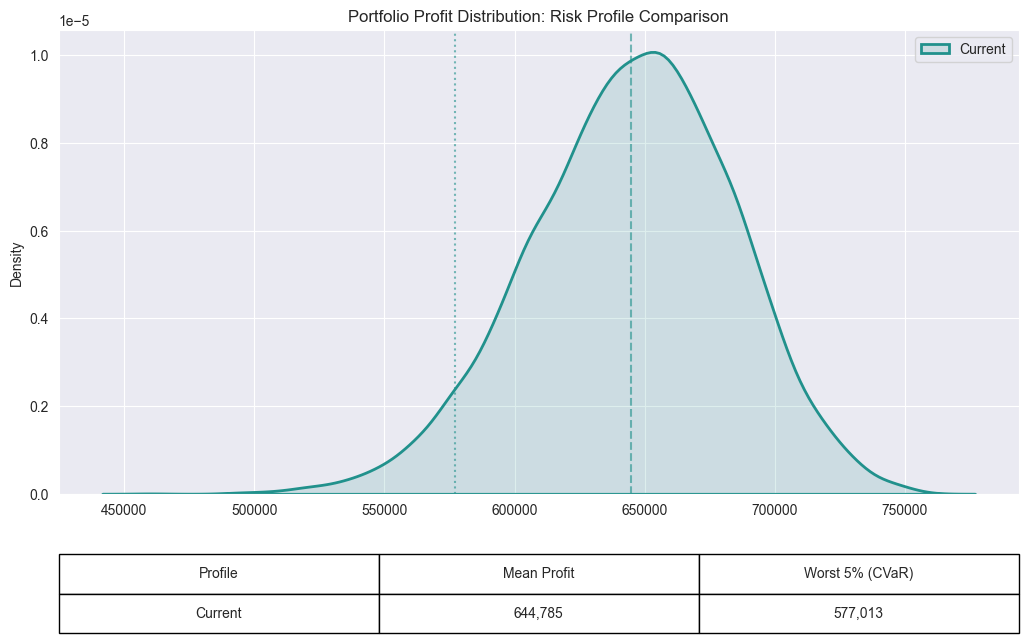

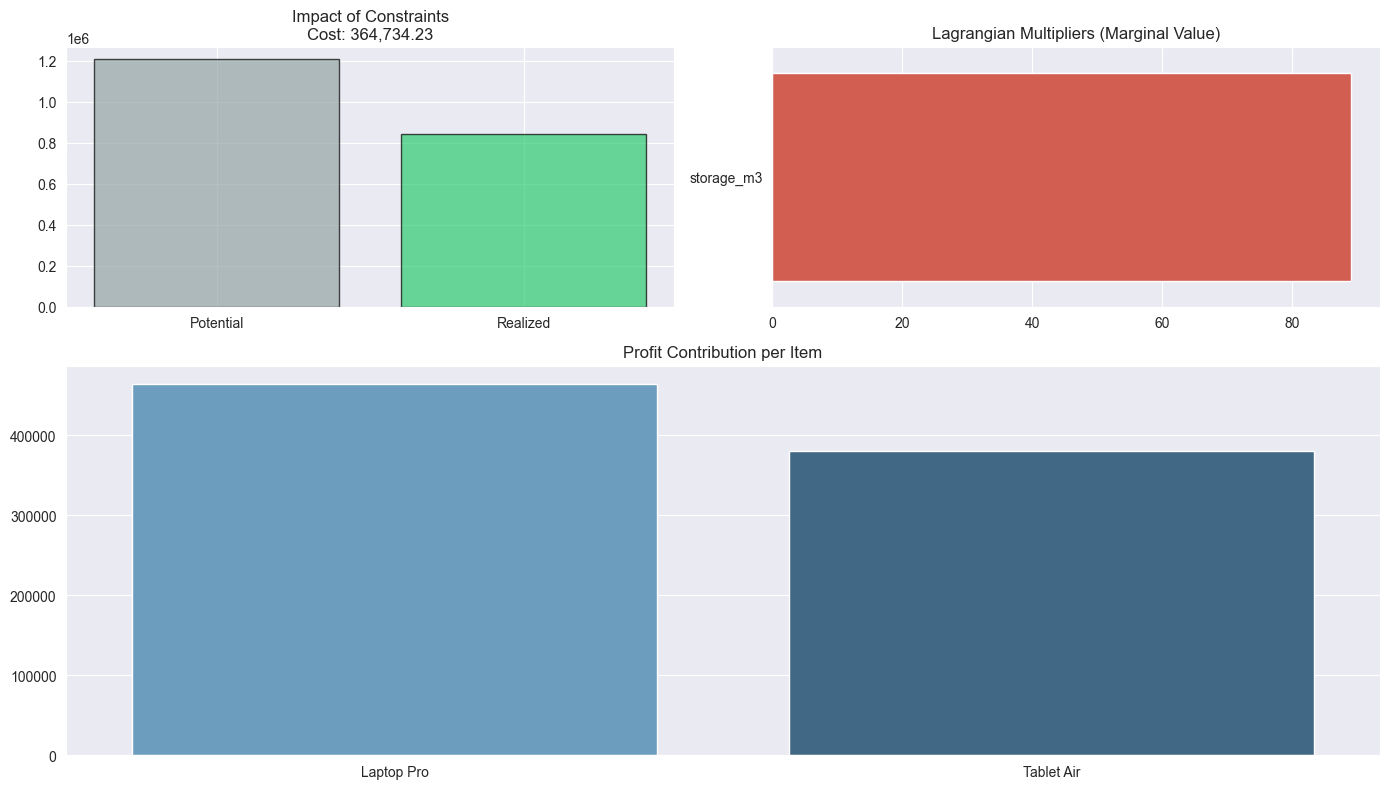

In [8]:
sk.plot_allocation()
sk.plot_item("Tablet Air")
sk.plot_risk()
sk.plot_optimization_summary()

---
## Production Run

Once you are satisfied with the holdout results, switch to `run()` to commit to a production allocation.

`run()` fits on the **full** history for each item (no data is withheld) and forecasts `forecast_days` days beyond the last observed date. It returns the same `allocation` and `solver_summary` fields, but no holdout `metrics` (there is no ground truth to compare against yet).

Here we switch to the SAA objective — pure expected-profit maximisation — now that we have validated the approach in holdout mode.

In [9]:
production_results = sk.run(
    forecast_days=14,
    events=events,
    objective="SAA",
    limits={"storage_m3": 5_000},
    fit_kwargs={"chain": 2, "samples": 500},
)

print("Planning period :", production_results["period"])
print("Mode            :", production_results["mode"])
print()

allocation_prod = production_results["allocation"]
for item_name, qty in allocation_prod.items():
    print(f"  {item_name:12s}  →  order {qty:>6,} units")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, growth, beta_event, beta_fourier, sigma]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 22 seconds.
Sampling: [y]


Output()

Sampling: [y]


...

Output()

Sampling: [y]


Output()

Planning period : ('2024-01-01', '2024-01-14')
Mode            : production

  Tablet Air    →  order  2,604 units
  Laptop Pro    →  order  1,458 units


C:\Users\bouwe\OneDrive\Desktop\GitCode\OptiStock\src\optistock\solvers.py:237: RuntimeWarning: divide by zero encountered in divide
  eu = float(np.mean(np.exp(-profits / self.risk_aversion)))


Text(0.5, 1.01, 'Laptop Pro — 14-day production forecast')

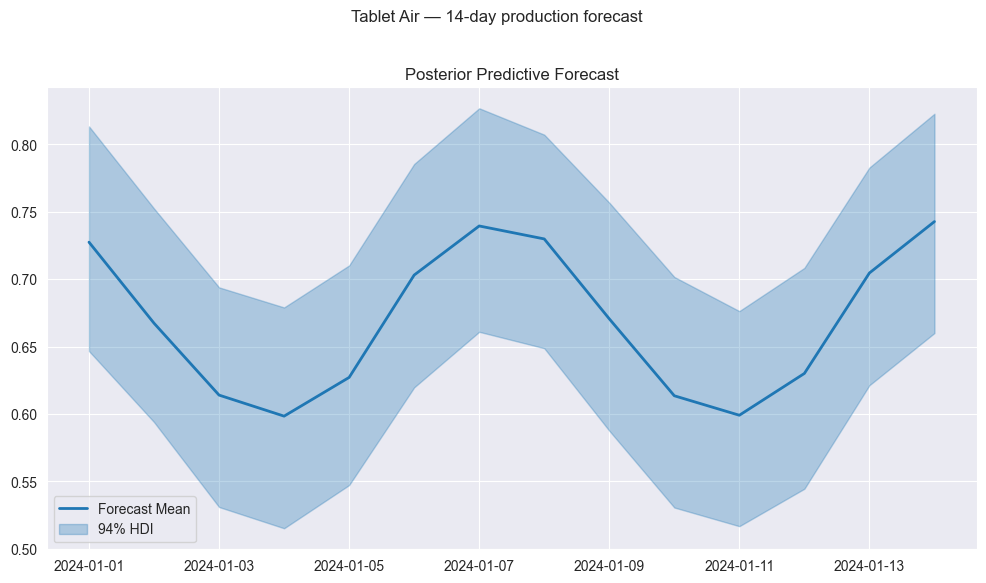

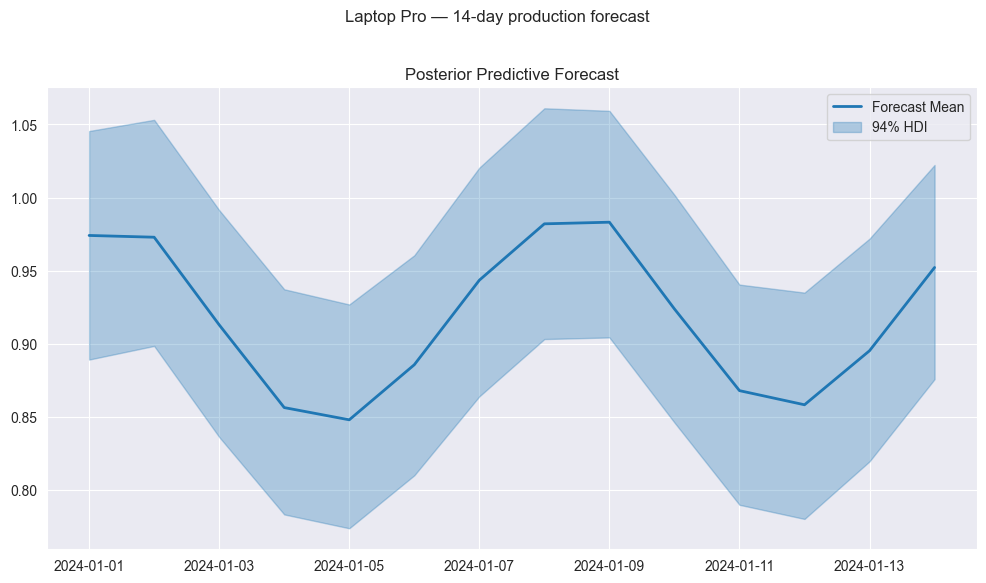

In [10]:
# Forecast plots for the production window (no holdout actuals to overlay)
fig_ta, _ = sk.plot_forecast("Tablet Air")
fig_ta.suptitle("Tablet Air — 14-day production forecast", y=1.01)

fig_lp, _ = sk.plot_forecast("Laptop Pro")
fig_lp.suptitle("Laptop Pro — 14-day production forecast", y=1.01)